### Libraries

In [1]:
import json
import random
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import roc_curve, auc, confusion_matrix
from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics import precision_recall_curve
from sklearn.model_selection import train_test_split
from torch import nn
from torch.nn.utils.rnn import pack_padded_sequence
from torch.utils.data import DataLoader, Dataset
from transformers import BertTokenizer

c:\Users\User\Documents\devanasokan_fyp\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Setup

In [2]:
# Set random seeds for reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

# Set deterministic behavior for CUDA operations
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
# Set up Hugging Face cache directory
cache_path = "../huggingface_cache"
cache_dir = Path(cache_path)
cache_dir.mkdir(parents=True, exist_ok=True)
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased", cache_dir=str(cache_dir))
print(f"Tokenizer vocab size: {len(tokenizer)}")

Tokenizer vocab size: 30522


In [4]:
# Set path for data
data_path = "../modeldata"

Choose between 2 different sets of data with different ratios

In [5]:
# Load the datasets (Ratio of 70:15:15 for train, validation, and test sets)
train_df = pd.read_csv(f"{data_path}/train70.csv")
val_df = pd.read_csv(f"{data_path}/val15.csv")
test_df = pd.read_csv(f"{data_path}/test15.csv")

ratio = "70:15:15"

In [6]:
# Load the datasets (Ratio of 80:10:10 for train, validation, and test sets)
train_df = pd.read_csv(f"{data_path}/train80.csv")
val_df = pd.read_csv(f"{data_path}/val10.csv")
test_df = pd.read_csv(f"{data_path}/test10.csv")

ratio = "80:10:10"

In [7]:
# Ratio used
print(f"Data split ratio: {ratio}")

Data split ratio: 80:10:10


Once a set has been chosen, continue with next steps

In [8]:
print(train_df['label'].value_counts(normalize=True))
print(val_df['label'].value_counts(normalize=True))
print(test_df['label'].value_counts(normalize=True))

label
1    0.5
0    0.5
Name: proportion, dtype: float64
label
1    0.5
0    0.5
Name: proportion, dtype: float64
label
0    0.5
1    0.5
Name: proportion, dtype: float64


In [9]:
print("train:", train_df.shape, train_df["label"].value_counts().sort_index().to_dict())
print("val:", val_df.shape, val_df["label"].value_counts().sort_index().to_dict())
print("test:", test_df.shape, test_df["label"].value_counts().sort_index().to_dict())

train: (18302, 2) {0: 9151, 1: 9151}
val: (2288, 2) {0: 1144, 1: 1144}
test: (2288, 2) {0: 1144, 1: 1144}


In [10]:
MAX_LEN = 180


def tokenize(text: str) -> list[str]:
    return tokenizer.tokenize(text)


counter = Counter()
for text in train_df["verse"]:
    counter.update(tokenize(text))

vocab = tokenizer.get_vocab()

print(f"Vocabulary size: {len(vocab)}")
print("Most common tokens:", counter.most_common(10))

Token indices sequence length is longer than the specified maximum sequence length for this model (657 > 512). Running this sequence through the model will result in indexing errors


Vocabulary size: 30522
Most common tokens: [(',', 216322), ('i', 54906), ('you', 40629), ('the', 31056), ('to', 24273), ('it', 20227), ('a', 19852), ('me', 18337), ('and', 17799), ('not', 15771)]


In [11]:
def numericalize(text: str) -> tuple[torch.Tensor, torch.Tensor]:
    token_ids = tokenizer.encode(
        text,
        add_special_tokens=False,
        truncation=True,
        max_length=MAX_LEN,
    )
    if not token_ids:
        token_ids = [tokenizer.unk_token_id]
    length = len(token_ids)
    if len(token_ids) < MAX_LEN:
        token_ids += [tokenizer.pad_token_id] * (MAX_LEN - len(token_ids))
    return torch.tensor(token_ids, dtype=torch.long), torch.tensor(length, dtype=torch.long)

sample_ids, sample_length = numericalize(train_df.iloc[0]["verse"] )
print("sample length:", sample_length.item())
print("sample ids:", sample_ids[:20].tolist())

sample length: 61
sample ids: [2026, 1010, 2026, 1010, 2092, 1010, 2009, 2003, 25085, 2066, 2057, 2024, 2035, 2183, 2000, 3280, 1010, 2035, 2183, 2000]


In [12]:
class LyricsDataset(Dataset):
    def __init__(self, frame: pd.DataFrame):
        self.texts = frame["verse"].tolist()
        self.labels = frame["label"].astype(np.float32).tolist()

    def __len__(self) -> int:
        return len(self.texts)

    def __getitem__(self, index: int):
        input_ids, length = numericalize(self.texts[index])
        label = torch.tensor(self.labels[index], dtype=torch.float32)
        return input_ids, length, label


In [13]:
# Create a seeded generator for the DataLoader
g = torch.Generator()
g.manual_seed(42)

batch_size = 128
train_loader = DataLoader(
    LyricsDataset(train_df), 
    batch_size=batch_size, 
    shuffle=True,
    generator=g,           
    num_workers=0          # for reproducibility
)
val_loader = DataLoader(LyricsDataset(val_df), batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(LyricsDataset(test_df), batch_size=batch_size, shuffle=False, num_workers=0)

batch_input_ids, batch_lengths, batch_labels = next(iter(train_loader))
print(batch_input_ids.shape, batch_lengths.shape, batch_labels.shape)

torch.Size([128, 180]) torch.Size([128]) torch.Size([128])


### Model Training

In [14]:
class LSTMClassifier(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        embedding_dim: int = 64,
        hidden_dim: int = 64,
        num_layers: int = 1,
        bidirectional: bool = True,
        dropout: float = 0.0,
    ):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=tokenizer.pad_token_id)
        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=bidirectional,
        )
        output_dim = hidden_dim * 2 if bidirectional else hidden_dim
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(output_dim, 1)

    def forward(self, input_ids: torch.Tensor, lengths: torch.Tensor) -> torch.Tensor:
        embedded = self.embedding(input_ids)
        packed = pack_padded_sequence(
            embedded,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False,
        )
        _, hidden = self.lstm(packed)
        if self.lstm.bidirectional:
            hidden = torch.cat((hidden[0][-2], hidden[0][-1]), dim=1)
        else:
            hidden = hidden[0][-1]
        logits = self.fc(self.dropout(hidden))
        return logits.squeeze(1)


model = LSTMClassifier(vocab_size=len(tokenizer)).to(device)
print(model)

LSTMClassifier(
  (embedding): Embedding(30522, 64, padding_idx=0)
  (lstm): LSTM(64, 64, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.0, inplace=False)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)


In [15]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


def run_epoch(loader: DataLoader, training: bool = True):
    model.train() if training else model.eval()

    total_loss = 0.0
    all_predictions = []
    all_probs = []
    all_targets = []

    for input_ids, lengths, labels in loader:
        input_ids = input_ids.to(device)
        lengths = lengths.to(device)
        labels = labels.to(device)

        with torch.set_grad_enabled(training):
            logits = model(input_ids, lengths)
            loss = criterion(logits, labels)

            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        # Get probability scores
        probs = torch.sigmoid(logits)
        all_probs.extend(probs.detach().cpu().tolist())

        predictions = (probs >= 0.5).long()
        all_predictions.extend(predictions.detach().cpu().tolist())
        all_targets.extend(labels.detach().cpu().long().tolist())
        total_loss += loss.item() * input_ids.size(0)

    average_loss = total_loss / len(loader.dataset)
    accuracy = accuracy_score(all_targets, all_predictions)
    return average_loss, accuracy, all_targets, all_probs, all_predictions


with torch.no_grad():
    preview_logits = model(batch_input_ids.to(device), batch_lengths.to(device))
print("preview logits shape:", preview_logits.shape)

preview logits shape: torch.Size([128])


In [16]:
# Training LSTM model over 10 epochs with early stopping based on validation loss

num_epochs = 10
best_val_acc = 0
best_model_path = Path("lstm_lyrics_classifier.pt")
history = []

# Add patience variables for early stopping
patience = 3
patience_counter = 0

for epoch in range(1, num_epochs + 1):
    train_loss, train_acc, _, _, _ = run_epoch(train_loader, training=True)
    val_loss, val_acc, _, _, _ = run_epoch(val_loader, training=False)

    history.append(
        {
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
        }
    )

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
    )

    # Check if validation accuracy improved
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0  # Reset patience counter when accuracy improves
        torch.save(model.state_dict(), best_model_path)
    else:
        patience_counter += 1  # Increment patience counter when accuracy doesn't improve

    # Early stopping logic - break if patience is exceeded
    if patience_counter >= patience:
        print(f"\nEarly stopping triggered! No improvement for {patience} consecutive epochs.")
        print(f"Best validation accuracy: {best_val_acc:.4f}")
        break

history_df = pd.DataFrame(history)
history_df

Epoch 01 | train_loss=0.6705 train_acc=0.5820 | val_loss=0.6236 val_acc=0.6442
Epoch 02 | train_loss=0.5820 train_acc=0.7018 | val_loss=0.5705 val_acc=0.7028
Epoch 03 | train_loss=0.5412 train_acc=0.7223 | val_loss=0.5535 val_acc=0.7120
Epoch 04 | train_loss=0.5558 train_acc=0.7185 | val_loss=0.5992 val_acc=0.6477
Epoch 05 | train_loss=0.5479 train_acc=0.7155 | val_loss=0.5830 val_acc=0.6718
Epoch 06 | train_loss=0.5128 train_acc=0.7405 | val_loss=0.5638 val_acc=0.7172
Epoch 07 | train_loss=0.4736 train_acc=0.7752 | val_loss=0.5392 val_acc=0.7373
Epoch 08 | train_loss=0.4465 train_acc=0.7932 | val_loss=0.5832 val_acc=0.6866
Epoch 09 | train_loss=0.4732 train_acc=0.7723 | val_loss=0.4960 val_acc=0.7627
Epoch 10 | train_loss=0.3939 train_acc=0.8250 | val_loss=0.4647 val_acc=0.7810


,epoch,train_loss,train_acc,val_loss,val_acc
0,1,0.670453,0.582013,0.623564,0.644231
1,2,0.581992,0.701836,0.570479,0.702797
2,3,0.541169,0.722325,0.553464,0.711976
3,4,0.555770,0.718501,0.599229,0.647727
4,5,0.547851,0.715496,0.582991,0.671766
5,6,0.512768,0.740466,0.563820,0.717220
6,7,0.473567,0.775216,0.539207,0.737325
7,8,0.446470,0.793192,0.583160,0.686626
8,9,0.473177,0.772265,0.496049,0.762675
9,10,0.393870,0.824992,0.464658,0.781031


### Model Evaluation and Saving

After training, reload the best checkpoint and evaluate it once on the test split. Then save the model and vocabulary together for inference.

In [17]:
# Load the best model and evaluate on the test set
model.load_state_dict(torch.load(best_model_path, map_location=device))
test_loss, test_acc, test_targets, test_probs, test_predictions = run_epoch(test_loader, training=False)

#### Classification Report

In [18]:
report = classification_report(
    test_targets,
    test_predictions,
    output_dict=True
)

accuracy = report["accuracy"]
precision = report["1"]["precision"]
recall = report["1"]["recall"]
f1 = report["1"]["f1-score"]

print(f"LSTM CLASSIFICATION REPORT (INITIAL - {ratio}):")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

LSTM CLASSIFICATION REPORT (INITIAL - 80:10:10):
Accuracy: 0.7836538461538461
Precision: 0.7854001759014951
Recall: 0.7805944055944056
F1-score: 0.7829899167032004


#### ROC-AUC Curve

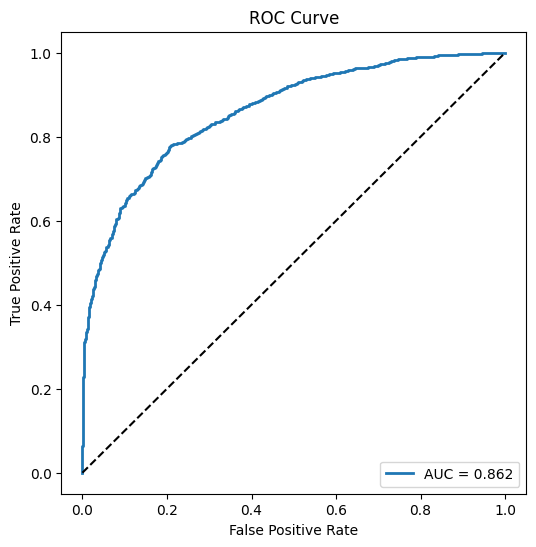

In [19]:
fpr, tpr, thresholds = roc_curve(test_targets, test_probs)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.3f}",
    linewidth=2
)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")

plt.show()

#### Precision-Recall Curve

PR-AUC: 0.8756463701120283


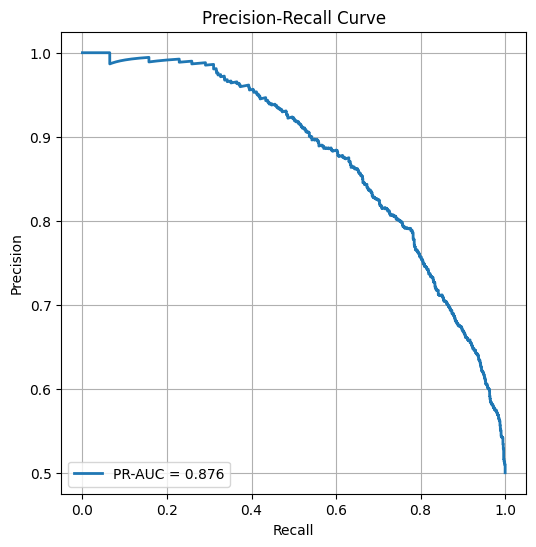

In [20]:
precision, recall, thresholds = precision_recall_curve(
    test_targets,
    test_probs
)

pr_auc = auc(recall, precision)

print("PR-AUC:", pr_auc)

plt.figure(figsize=(6,6))

plt.plot(
    recall,
    precision,
    label=f"PR-AUC = {pr_auc:.3f}",
    linewidth=2
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.legend(loc="lower left")
plt.grid()

plt.show()

#### Confusion Matrix

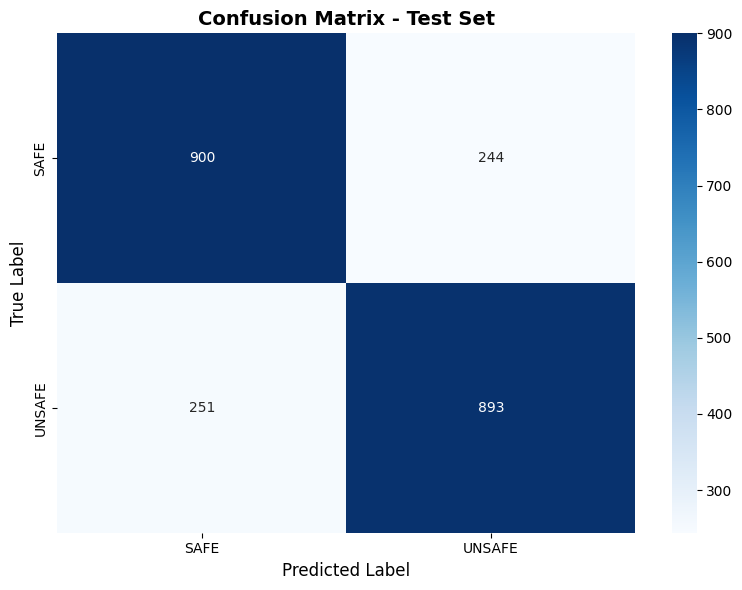

In [21]:
# Confusion matrix
cm = pd.crosstab(pd.Series(test_targets, name="Actual"), pd.Series(test_predictions, name="Predicted"))

# Create the plot
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, 
    annot=True,  # Show numbers in cells
    fmt='d',     # Format as integers
    cmap='Blues',  # Color palette
    cbar=True,   # Show color bar
    xticklabels=['SAFE', 'UNSAFE'],
    yticklabels=['SAFE', 'UNSAFE']
)
 
plt.title('Confusion Matrix - Test Set', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

In [22]:
# Save the model and vocabulary
artifact_dir = Path("lstm_artifacts")
artifact_dir.mkdir(exist_ok=True)

model_path = artifact_dir / "lyrics_lstm.pt"
vocab_path = artifact_dir / "lyrics_vocab.json"

torch.save(model.state_dict(), model_path)
with open(vocab_path, "w", encoding="utf-8") as vocab_file:
    json.dump(vocab, vocab_file, ensure_ascii=False, indent=2)

In [23]:
def predict_text(text: str):
    model.eval()
    input_ids, length = numericalize(text)
    with torch.no_grad():
        logits = model(input_ids.unsqueeze(0).to(device), length.unsqueeze(0).to(device))
        probability = torch.sigmoid(logits).item()
        prediction = int(probability >= 0.5)
    return probability, prediction


sample_probability, sample_prediction = predict_text("im drinking coffee and feeling great, got to get back to work now, but i feel good about the day ahead, ")
print({"probability": sample_probability, "prediction": sample_prediction})

{'probability': 0.8819364309310913, 'prediction': 1}
